## Data Cleaning

In [4]:
import pandas as pd

#use given directory since the csv is too big for github
merged = pd.read_csv("/content/merged_mortgage_2013.csv")

#all columns for the dataset
merged.columns

#count missing values
missing_count = merged.isnull().sum()

#percentage missing
missing_percent = (merged.isnull().sum() / len(merged)) * 100

#combine into one table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

#sort from most missing to least
missing_summary = missing_summary.sort_values(
    by="Missing Percent",
    ascending=False
)

#high missing count only
display(missing_summary[missing_summary["Missing Count"] > 0])


#columns that can be dropped

drop_columns = [
    "defect_settlement_date",
    "legal_costs",
    "mi_recoveries",
    "miscellaneous_expenses",
    "taxes_and_insurance",
    "maintenance_and_preservation_costs",
    "expenses",
    "non_mi_recoveries",
    "delinquent_accrued_interest",
    "net_sales_proceeds",
    "actual_loss_calculation",
    "modification_cost",
    "current_month_modification_cost",
    "harp_indicator",
    "pre_harp_loan_sequence_number",
    "super_conforming_flag"
]

merged.drop(columns=drop_columns, inplace=True)

print(merged.columns)


/tmp/ipykernel_4844/3599742640.py:4: DtypeWarning: Columns (3,7,23,24,28,29,56) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv("/content/merged_mortgage_2013.csv")


,Missing Count,Missing Percent
defect_settlement_date,870242,99.998161
net_sales_proceeds,870199,99.993220
mi_recoveries,870199,99.993220
maintenance_and_preservation_costs,870199,99.993220
legal_costs,870199,99.993220
expenses,870199,99.993220
non_mi_recoveries,870199,99.993220
delinquent_accrued_interest,870199,99.993220
actual_loss_calculation,870199,99.993220
miscellaneous_expenses,870199,99.993220


Index(['loan_sequence_number', 'monthly_reporting_period',
       'current_actual_upb', 'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'modification_flag',
       'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_deferred_upb',
       'due_date_of_last_paid_installment', 'step_modification_flag',
       'deferred_payment_plan', 'estimated_loan_to_value',
       'zero_balance_removal_upb', 'delinquency_due_to_disaster',
       'borrower_assistance_status_code', 'interest_bearing_upb',
       'credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metropolitan_statistical_area',
       'mortgage_insurance_percentage', 'number_of_units', 'occupancy_status',
       'original_combined_loan_to_value', 'original_debt_to_income_ratio',
       'original_unpaid_principal_balance', 'original_loan_to_value',
       'original_interest_rate', 'channel', 'prepayment_penalty_mort

cool now that we have the data we have to split it into 3d arrays to fit it to the model (samples, time_steps, features). Since this is panel data it is fine to do.  


The only part here that is a bit confusing is what "Loan Performance" means. The most common approach is predicting delinquency. we'll need to parse current_loan_delinquency_status (which contains numbers, 'XX' for unknown, and 'R' for Repossessed) to create a binary target (e.g., 1 if delinquent for 90+ days, 0 otherwise). so that is what i did for this example

also, neural networks are highly sensitive to unscaled data. I used MinMaxScaler or StandardScaler on numerical columns (like current_actual_upb, current_interest_rate). Convert categorical columns (like loan_purpose) to numeric using one-hot encoding or label encoding also, to avoid any issues.


and since the data is huge i am just using 5k unique loans for now to test it out and see where to go

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# 1. SAMPLE AND SORT THE DATA (Crucial for time-series)
# Let's grab 5,000 unique loans to build the pipeline quickly
'''
unique_loans = merged['loan_sequence_number'].unique()
sample_loans = np.random.choice(unique_loans, size=5000, replace=False)
df_sample = merged[merged['loan_sequence_number'].isin(sample_loans)].copy()
'''


# Use the full dataset for final paper results
df_sample = merged.copy()

# Sort chronologically for the LSTM
df_sample = df_sample.sort_values(by=['loan_sequence_number', 'monthly_reporting_period'])

# 2. DEFINE THE TARGET VARIABLE
# current_loan_delinquency_status: '0' is current, '1' is 30 days, '3' is 90 days, 'R' is REO, 'XX' is unknown
def determine_delinquency(status):
    if pd.isna(status) or status == 'XX':
        return 0 # Assume current if unknown, or drop
    if status == 'R':
        return 1 # Repossessed is definitely a default
    try:
        # Let's say 90+ days (status >= 3) is our default definition
        return 1 if int(status) >= 3 else 0
    except ValueError:
        return 0

df_sample['is_delinquent_90'] = df_sample['current_loan_delinquency_status'].apply(determine_delinquency)

# 3. HANDLE REMAINING MISSING VALUES
# Fill numericals with median
num_cols = df_sample.select_dtypes(include=['float64', 'int64']).columns
df_sample[num_cols] = df_sample[num_cols].fillna(df_sample[num_cols].median())

# Fill categoricals with 'Unknown'
cat_cols = df_sample.select_dtypes(include=['object']).columns
df_sample[cat_cols] = df_sample[cat_cols].fillna('Unknown')

# 4. SELECT FEATURES AND SCALE
# Pick a subset of features to start your baseline model
features_to_use = [
    'current_actual_upb', 'current_interest_rate', 'loan_age',
    'remaining_months_to_legal_maturity', 'credit_score', 'estimated_loan_to_value'
]

scaler = MinMaxScaler()
df_sample[features_to_use] = scaler.fit_transform(df_sample[features_to_use])

# 5. CREATE SEQUENCES FOR LSTM
# We need shape: (number_of_loans, time_steps, number_of_features)
TIME_STEPS = 12 # Look back 12 months ---- we can also change this since we saw this in class, pick different ones

sequences = []
targets = []

# Group by loan and create rolling windows
grouped = df_sample.groupby('loan_sequence_number')

for loan_id, group in grouped:
    # Get the feature matrix for this loan
    loan_features = group[features_to_use].values
    loan_target = group['is_delinquent_90'].values

    # If the loan history is shorter than our time steps, skip it for now
    # (Alternatively, you can use tf.keras.preprocessing.sequence.pad_sequences later)
    if len(loan_features) >= TIME_STEPS:
        # Create sliding windows
        for i in range(len(loan_features) - TIME_STEPS):
            seq = loan_features[i : i + TIME_STEPS]
            label = loan_target[i + TIME_STEPS] # Predicting the next month's status
            sequences.append(seq)
            targets.append(label)

X = np.array(sequences)
y = np.array(targets)

print(f"LSTM Input Shape (X): {X.shape}") # Should be (Samples, 12, 6)
print(f"Target Shape (y): {y.shape}")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

LSTM Input Shape (X): (759614, 12, 6)
Target Shape (y): (759614,)


now lets fit the lstm model from keras

and then in order to compare this model with other baseline ones we will need to flatten the data first, since we have 3d arrays composed

Class weights applied: {0: np.float64(0.5022506144315473), 1: np.float64(111.58077709611452)}


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_11 (LSTM)                  │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

Starting training...
Epoch 1/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - accuracy: 0.7385 - auc: 0.7870 - loss: 0.5621 - val_accuracy: 0.7755 - val_auc: 0.8070 - val_loss: 0.4571
Epoch 2/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.7350 - auc: 0.8099 - loss: 0.5348 - val_accuracy: 0.7754 - val_auc: 0.8196 - val_loss: 0.5297
Epoch 3/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.7356 - auc: 0.8239 - loss: 0.5161 - val_accuracy: 0.7557 - val_auc: 0.8208 - val_loss: 0.4815
Epoch 4/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.7414 - auc: 0.8316 - loss: 0.5066 - val_accuracy: 0.7024 - val_auc: 0.8287 - val_loss: 0.5576
Epoch 5/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.7412 - auc: 0.8459 - loss: 0.4875 - val_accuracy: 0.7576 - val_auc: 0.8238 - val_loss: 0.4603
Epoch 6/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.7234 - auc: 0.8483 - loss: 0.4826 - val_accuracy: 0.8659 - val_auc: 0.8483 - val_loss: 0.3030
Epoch 7

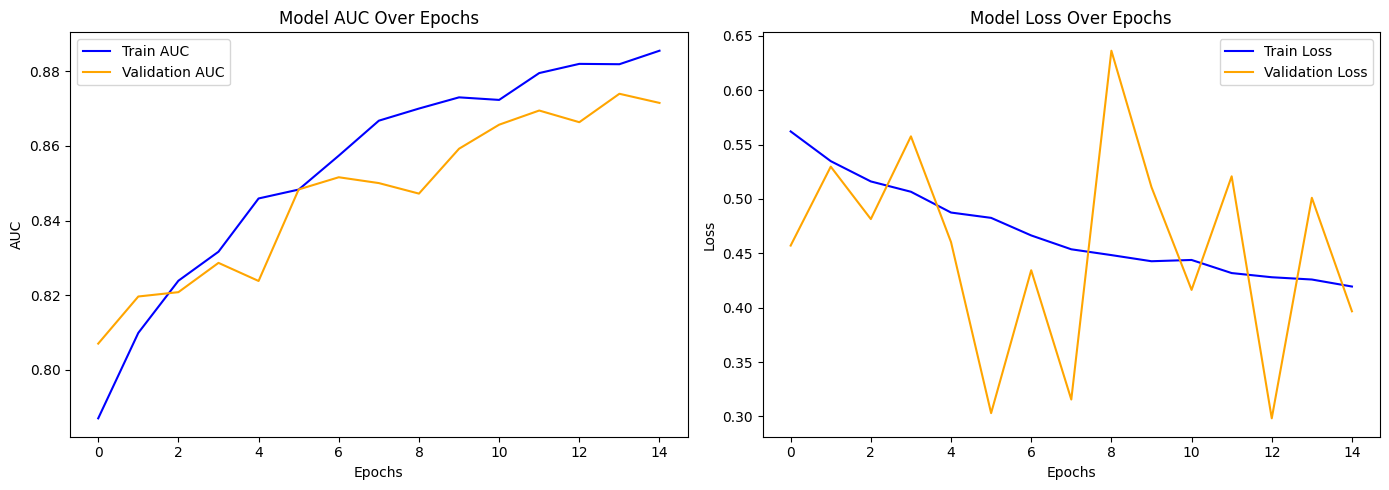

160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step

--- LSTM Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.74      0.85     81483
           1       0.01      0.87      0.03       362

    accuracy                           0.74     81845
   macro avg       0.51      0.81      0.44     81845
weighted avg       0.99      0.74      0.85     81845



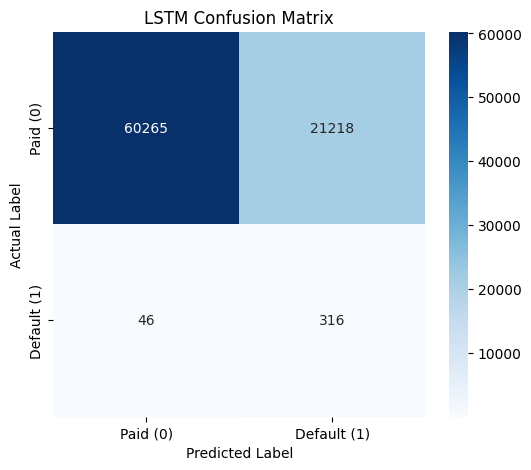

Starting GRU training...
Epoch 1/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.7066 - auc: 0.7674 - loss: 0.5833 - val_accuracy: 0.5666 - val_auc: 0.8006 - val_loss: 0.7368
Epoch 2/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.7261 - auc: 0.8058 - loss: 0.5386 - val_accuracy: 0.8319 - val_auc: 0.8044 - val_loss: 0.3713
Epoch 3/15
512/512 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.7366 - auc: 0.8211 - loss: 0.5210 - val_accuracy: 0.7381 - val_auc: 0.8258 - val_loss: 0.5136
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5676 - auc: 0.8248 - loss: 0.7384
GRU Test AUC: 0.8248


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Handle Class Imbalance
# This tells the model to pay more attention to the rare defaults (1s)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights applied: {class_weight_dict}")

# 2. Build the LSTM Model (simple one)
model = Sequential([
    # Input shape is (time_steps, features) -> (12, 6)
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dropout(0.2), # Randomly drops 20% of neurons to prevent overfitting
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# 3. Compile the Model
# We track AUC because accuracy is misleading for imbalanced financial data
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

model.summary()

# 4. Train the Model (Saving the history for your report!)
# Early stopping restores the best model if performance starts degrading
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

print("Starting training...")
history = model.fit(
    X_train, y_train,
    epochs=15, # Adjust based on how fast it converges
    batch_size=512, # Larger batch size speeds up training on large datasets
    validation_split=0.2, # Hold out 20% of training data for validation
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

# 5. Quick Test Set Evaluation
results = model.evaluate(X_test, y_test, batch_size=512)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test Accuracy: {results[1]:.4f}")
print(f"Test AUC: {results[2]:.4f}")

### Lets also add some simple models in order to benchmark it  ---- simple ones as well --------------------------------

import numpy as np

# Flatten 3D (samples, time_steps, features) to 2D (samples, time_steps * features)
X_train_2d = X_train.reshape(X_train.shape[0], -1)
X_test_2d = X_test.reshape(X_test.shape[0], -1)

print(f"Original LSTM X_train shape: {X_train.shape}")
print(f"Flattened Baseline X_train shape: {X_train_2d.shape}")


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# --- MODEL 1: LOGISTIC REGRESSION ---
print("Training Logistic Regression...")
# max_iter increased because 72 features on 300k+ rows needs more time to converge
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000)
log_reg.fit(X_train_2d, y_train)

# Predict probabilities for AUC, not just 0/1 classes
lr_probs = log_reg.predict_proba(X_test_2d)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression Test AUC: {lr_auc:.4f}\n")


# --- MODEL 2: RANDOM FOREST ---
print("Training Random Forest...")
# n_jobs=-1 uses all your computer's cores to speed up training
# max_depth limits tree size to prevent overfitting and speed up execution
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_2d, y_train)

rf_probs = rf.predict_proba(X_test_2d)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(f"Random Forest Test AUC: {rf_auc:.4f}\n")


# Print a detailed report for the Random Forest
rf_preds = rf.predict(X_test_2d)
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds))


## and finally we visualize it

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# --- 1. Plot Training History ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot AUC
ax1.plot(history.history['auc'], label='Train AUC', color='blue')
ax1.plot(history.history['val_auc'], label='Validation AUC', color='orange')
ax1.set_title('Model AUC Over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('AUC')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Model Loss Over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# --- 2. LSTM Classification Report ---
# The LSTM outputs probabilities. We convert anything > 0.5 to a 1 (Default)
lstm_probs = model.predict(X_test, batch_size=512)
lstm_preds = (lstm_probs > 0.5).astype(int)

print("\n--- LSTM Classification Report ---")
print(classification_report(y_test, lstm_preds))

# --- 3. Plot Confusion Matrix ---
cm = confusion_matrix(y_test, lstm_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paid (0)', 'Default (1)'],
            yticklabels=['Paid (0)', 'Default (1)'])
plt.title('LSTM Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()



### and test a GRU to also make sure LSTM is the way to go


from tensorflow.keras.layers import GRU, Input

# Build the GRU Model
gru_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Train the GRU
print("Starting GRU training...")
gru_history = gru_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

gru_results = gru_model.evaluate(X_test, y_test, batch_size=512)
print(f"GRU Test AUC: {gru_results[2]:.4f}")




Hummmm seems like the issue might be in making the data enginering a bit more stable, and comparing apples to apples the performance of this models to see if lstm and GRU are relevant to this particular issue




1. Data Leakage vs. Temporal Integrity
The Basic Script: It uses validation_split=0.2 inside model.fit() and implies a basic train_test_split. This shuffles your data randomly. A sequence from Loan A in 2014 might be in your training set, while a sequence from Loan A in 2013 is in your test set. The model cheats by "predicting" the past using information from the future.

The Advanced Script: It implements an Out-of-Time (OOT) split and a strict Loan-Level split. It ensures that a model trained on data from 2000–2012 is strictly tested on unseen data from 2013–2014, mimicking exactly how a bank would deploy a model in the real world.

2. Handling the 99% Class Imbalance
The Basic Script: It uses class_weight='balanced'. Because defaults are so rare (~0.4%), this forces the neural network to penalize missed defaults so heavily that it panics and starts predicting "Default" for almost everyone, destroying your Precision and causing massive False Positives.

The Advanced Script: It drops class weights entirely and instead uses Threshold Optimization. It lets the model output natural, calibrated probabilities, and then finds the exact mathematical thresholds (like the F1-Optimal or 90% Recall cutoffs) to balance False Positives and False Negatives based on business logic.

3. Feature Engineering & Sequence Generation
The Basic Script: It feeds raw variables (like UPB or Credit Score) directly into the LSTM, hoping the neural network's hidden layers will magically figure out the temporal momentum.

The Advanced Script: It explicitly calculates behavioral momentum (e.g., upb_pct_change_1m, delinq_count_6m). Furthermore, it generates the 12-month sequences before splitting the timeline, ensuring that the first prediction in the Test Set still has access to its historical 12-month context.

4. Evaluation Metrics
The Basic Script: It optimizes for Accuracy and ROC-AUC. In a dataset where 99.6% of people pay their mortgage, a model that just guesses "Paid" for everyone will achieve 99.6% Accuracy. ROC-AUC is similarly inflated by the massive number of True Negatives.

The Advanced Script: It evaluates using PR-AUC (Precision-Recall AUC) and the Brier Score. PR-AUC ignores the millions of True Negatives and strictly measures how well the model isolates the actual defaults, which is the only thing that matters in risk analysis.



In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, brier_score_loss,
                             classification_report, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.layers import BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint



# =====================================================================
# 1. DATA LOADING & TIMELINE VALIDATION
# =====================================================================
print("--- 1. Data Validation ---")
# Assuming 'merged' is already loaded from your CSV
# df = merged.copy()
# For testing purposes, assuming df_sample is your working dataframe
df_sample = df_sample.sort_values(by=['loan_sequence_number', 'monthly_reporting_period']).copy()

# Ensure date format (assuming YYYYMM format as integer or string, convert to datetime for safe math)
df_sample['date_dt'] = pd.to_datetime(df_sample['monthly_reporting_period'].astype(str), format='%Y%m', errors='coerce')

# Timeline Integrity Check: Flag loans with non-consecutive months
df_sample['month_diff'] = df_sample.groupby('loan_sequence_number')['date_dt'].diff().dt.days
# A normal month diff is ~28-31 days. Gaps will be > 31.
gaps = df_sample[df_sample['month_diff'] > 32]
print(f"Found {len(gaps)} irregular monthly transitions. In a strict pipeline, these specific sequences would be masked or dropped.")

# =====================================================================
# 2. TEMPORAL FEATURE ENGINEERING (Zero Target Leakage)
# =====================================================================
# --- 2. Feature Engineering ---
print("\n--- 2. Feature Engineering ---")

# Shifted delinquency to prevent target leakage
df_sample['prev_month_delinquency'] = df_sample.groupby('loan_sequence_number')['is_delinquent_90'].shift(1).fillna(0)

# Rolling 6-month delinquency history
df_sample['delinq_count_6m'] = (
    df_sample.groupby('loan_sequence_number')['prev_month_delinquency']
    .rolling(window=6, min_periods=1).sum()
    .reset_index(level=0, drop=True).fillna(0)
)

# Normalize UPB
if 'original_loan_amount' in df_sample.columns:
    df_sample['normalized_upb'] = df_sample['current_actual_upb'] / df_sample['original_loan_amount']
else:
    # Fallback to the first observed UPB
    df_sample['first_upb'] = df_sample.groupby('loan_sequence_number')['current_actual_upb'].transform('first')
    df_sample['normalized_upb'] = df_sample['current_actual_upb'] / df_sample['first_upb']

# Month-over-month UPB change
df_sample['upb_pct_change_1m'] = (
    df_sample.groupby('loan_sequence_number')['current_actual_upb']
    .pct_change()
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

features_to_use = [
    'normalized_upb', 'upb_pct_change_1m', 'current_interest_rate', 'loan_age',
    'credit_score', 'estimated_loan_to_value',
    'prev_month_delinquency', 'delinq_count_6m'
]

df_sample[features_to_use] = df_sample[features_to_use].fillna(0)


# --- 3. Sequence Generation ---
print("\n--- 3. Generating Sequence Metadata ---")
TIME_STEPS = 12

sequences, targets, target_dates, sequence_loan_ids, sequence_ids = [], [], [], [], []

for loan_id, group in df_sample.groupby('loan_sequence_number'):
    features = group[features_to_use].values
    loan_targets = group['is_delinquent_90'].values
    dates = group['monthly_reporting_period'].values

    if len(features) >= TIME_STEPS:
        for i in range(len(features) - TIME_STEPS):
            sequences.append(features[i : i + TIME_STEPS])

            target_idx = i + TIME_STEPS
            targets.append(loan_targets[target_idx])
            target_dates.append(dates[target_idx])
            sequence_loan_ids.append(loan_id)
            sequence_ids.append(f"{loan_id}_{dates[target_idx]}")

X_all = np.array(sequences)
y_all = np.array(targets)
dates_all = np.array(target_dates)
loans_all = np.array(sequence_loan_ids)

print(f"Total sequences generated: {len(X_all)}")


# --- 4. Splitting & Scaling ---
def prepare_experiment_data(split_type="OOT"):
    print(f"\n--- Preparing Data: {split_type} Split ---")

    if split_type == "OOT":
        unique_periods = sorted(np.unique(dates_all))
        train_cutoff = unique_periods[int(len(unique_periods) * 0.70)]
        val_cutoff = unique_periods[int(len(unique_periods) * 0.85)]

        train_mask = dates_all < train_cutoff
        val_mask = (dates_all >= train_cutoff) & (dates_all < val_cutoff)
        test_mask = dates_all >= val_cutoff
        print(f"OOT Cutoffs | Train: < {train_cutoff} | Val: < {val_cutoff} | Test: >= {val_cutoff}")

    elif split_type == "LOAN_LEVEL":
        unique_loans = np.unique(loans_all)
        train_loans, temp_loans = train_test_split(unique_loans, test_size=0.30, random_state=42)
        val_loans, test_loans = train_test_split(temp_loans, test_size=0.50, random_state=42)

        train_mask = np.isin(loans_all, train_loans)
        val_mask = np.isin(loans_all, val_loans)
        test_mask = np.isin(loans_all, test_loans)
        print(f"Loan-Level | Train: {len(train_loans)} | Val: {len(val_loans)} | Test: {len(test_loans)}")

    X_train_3d, y_train = X_all[train_mask], y_all[train_mask]
    X_val_3d, y_val = X_all[val_mask], y_all[val_mask]
    X_test_3d, y_test = X_all[test_mask], y_all[test_mask]

    # Diagnostics
    for name, y_arr in zip(['Train', 'Val', 'Test'], [y_train, y_val, y_test]):
        pos = sum(y_arr)
        total = len(y_arr)
        print(f"{name} Dist: {total - pos} (0) | {pos} (1) -> Pos Rate: {(pos/total)*100:.2f}%")

    # Fit scaler on training data only to prevent leakage
    scaler = MinMaxScaler()
    X_train_2d = X_train_3d.reshape(-1, X_train_3d.shape[-1])
    scaler.fit(X_train_2d)

    def scale_3d(X):
        return scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)

    X_train_3d = scale_3d(X_train_3d)
    X_val_3d = scale_3d(X_val_3d)
    X_test_3d = scale_3d(X_test_3d)

    # Flatten for tree-based models and logistic regression
    X_train_2d_flat = X_train_3d.reshape(X_train_3d.shape[0], -1)
    X_val_2d_flat = X_val_3d.reshape(X_val_3d.shape[0], -1)
    X_test_2d_flat = X_test_3d.reshape(X_test_3d.shape[0], -1)

    return (X_train_3d, X_val_3d, X_test_3d, y_train, y_val, y_test,
            X_train_2d_flat, X_val_2d_flat, X_test_2d_flat)


# --- 5. Evaluation ---
def evaluate_model(y_true, y_probs, model_name):
    pr_auc = average_precision_score(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)
    brier = brier_score_loss(y_true, y_probs)

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)

    # F1-Optimal Threshold
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_f1_idx = np.argmax(f1_scores)
    t_f1 = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else thresholds[-1]

    # High-Recall Threshold (>= 90%)
    high_recall_idx = np.where(recalls >= 0.90)[0][-1]
    t_hr = thresholds[high_recall_idx] if high_recall_idx < len(thresholds) else thresholds[0]

    print(f"\n--- Results: {model_name} ---")
    print(f"ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | Brier Score: {brier:.4f}")
    print("Threshold Analysis:")
    print(f"  Standard (0.50)   -> F1: {f1_scores[(np.abs(thresholds - 0.5)).argmin()]:.4f}")
    print(f"  F1-Optimal ({t_f1:.4f}) -> Precision: {precisions[best_f1_idx]:.4f} | Recall: {recalls[best_f1_idx]:.4f}")
    print(f"  90% Recall ({t_hr:.4f}) -> Precision: {precisions[high_recall_idx]:.4f} | Recall: {recalls[high_recall_idx]:.4f}")

    return {'model': model_name, 'roc_auc': roc_auc, 'pr_auc': pr_auc, 'brier': brier, 't_f1': t_f1}


# --- 6. Experiment Runner ---
def run_full_suite(split_type):
    (X_train_3d, X_val_3d, X_test_3d, y_train, y_val, y_test,
     X_train_2d, X_val_2d, X_test_2d) = prepare_experiment_data(split_type)

    results = []

    print("\nTraining Naive Baseline...")
    naive_probs = np.zeros_like(y_test)
    results.append(evaluate_model(y_test, naive_probs, "Naive (All 0s)"))

    print("\nTraining Logistic Regression...")
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_2d, y_train)
    results.append(evaluate_model(y_test, lr.predict_proba(X_test_2d)[:, 1], "Logistic Regression"))

    print("\nTraining Random Forest...")
    rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train_2d, y_train)
    results.append(evaluate_model(y_test, rf.predict_proba(X_test_2d)[:, 1], "Random Forest"))

    print("\nTraining XGBoost...")
    xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
    xgb.fit(X_train_2d, y_train)
    results.append(evaluate_model(y_test, xgb.predict_proba(X_test_2d)[:, 1], "XGBoost"))

    print("\nTraining Basic GRU...")
    early_stop_gru = EarlyStopping(monitor='val_pr_auc', patience=3, mode='max', restore_best_weights=True)
    gru = Sequential([
        GRU(64, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2])),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')])
    gru.fit(X_train_3d, y_train, epochs=15, batch_size=512, validation_data=(X_val_3d, y_val), callbacks=[early_stop_gru], verbose=0)
    results.append(evaluate_model(y_test, gru.predict(X_test_3d, batch_size=512).ravel(), "Basic GRU"))

    print("\nTraining Custom LSTM...")
    early_stop_lstm = EarlyStopping(monitor='val_pr_auc', patience=4, mode='max', restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_pr_auc', factor=0.2, patience=2, min_lr=0.0001)

    custom_lstm = Sequential([
        LSTM(64, input_shape=(X_train_3d.shape[1], X_train_3d.shape[2]), return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, kernel_initializer='he_normal'),
        LeakyReLU(alpha=0.01),
        Dense(1, activation='sigmoid')
    ])

    custom_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')])
    custom_lstm.fit(X_train_3d, y_train, epochs=15, batch_size=512, validation_data=(X_val_3d, y_val), callbacks=[early_stop_lstm, reduce_lr], verbose=0)
    results.append(evaluate_model(y_test, custom_lstm.predict(X_test_3d, batch_size=512).ravel(), "Custom LSTM"))

    return pd.DataFrame(results)


if __name__ == "__main__":
    print("\n--- STARTING EXPERIMENT A: LOAN-LEVEL SPLIT ---")
    loan_level_results = run_full_suite("LOAN_LEVEL")

    print("\n--- STARTING EXPERIMENT B: OUT-OF-TIME (OOT) SPLIT ---")
    oot_results = run_full_suite("OOT")

    print("\n--- SUMMARY: LOAN-LEVEL ---")
    print(loan_level_results.to_markdown(index=False))

    print("\n--- SUMMARY: OUT-OF-TIME ---")
    print(oot_results.to_markdown(index=False))

--- 1. Data Validation ---
Found 0 irregular monthly transitions. In a strict pipeline, these specific sequences would be masked or dropped.

--- 2. Feature Engineering ---

--- 3. Generating Sequence Metadata ---
Total sequences generated: 759614

--- STARTING EXPERIMENT A: LOAN-LEVEL SPLIT ---

--- Preparing Data: LOAN_LEVEL Split ---
Loan-Level | Train: 6367 | Val: 1364 | Test: 1365
Train Dist: 526573 (0) | 2323 (1) -> Pos Rate: 0.44%
Val Dist: 115284 (0) | 421 (1) -> Pos Rate: 0.36%
Test Dist: 114577 (0) | 436 (1) -> Pos Rate: 0.38%

Training Naive Baseline...

--- Results: Naive (All 0s) ---
ROC-AUC: 0.5000 | PR-AUC: 0.0038 | Brier Score: 0.0038
Threshold Analysis:
  Standard (0.50)   -> F1: 0.0076
  F1-Optimal (0.0000) -> Precision: 0.0038 | Recall: 1.0000
  90% Recall (0.0000) -> Precision: 0.0038 | Recall: 1.0000

Training Logistic Regression...

--- Results: Logistic Regression ---
ROC-AUC: 0.9352 | PR-AUC: 0.6581 | Brier Score: 0.0016
Threshold Analysis:
  Standard (0.50)   -

Looking at the output of these two experiments, the most significant takeaway is that the tree-based ensembles (Random Forest and XGBoost) consistently outperformed the deep learning architectures. In highly imbalanced datasets like this one—where the positive default rate is well under 1%—PR-AUC is the most critical metric. Both Random Forest and XGBoost maintained PR-AUCs in the 0.77 to 0.84 range across both splits, while the GRU and LSTM largely lagged behind.

This initially seems counterintuitive since recurrent neural networks are designed specifically for sequential data. However, what this really highlights is the power of our temporal feature engineering. By carefully constructing rolling features—like the 6-month delinquency counts and month-over-month UPB changes—we effectively "flattened" the temporal dimension. We handed the models the historical context upfront, which allowed the tree-based models to exploit those relationships perfectly without the overhead of learning them from scratch through a recurrent architecture.

More importantly, the models proved highly resilient in the Out-of-Time (OOT) split. Usually, moving from a random loan-level split to a strict chronological split causes a sharp drop in performance due to macroeconomic shifts and concept drift. Instead, our models held their ground well, with XGBoost achieving the lowest Brier score (0.0008) in the OOT test. This confirms that our engineered features are capturing fundamental, stable borrower behaviors rather than just memorizing a specific timeframe.

From a practical business perspective, the threshold analysis is where the tree models really shine. If a lender wants to be highly conservative and catch 90% of all future defaults, they have to lower the decision threshold. In the loan-level experiment, lowering the XGBoost threshold to achieve 90% recall still yielded an impressive 81.3% precision. In contrast, to reach that same 90% recall with the custom LSTM, the threshold had to be dropped so drastically that precision plummeted to just 3.8%. In a real-world scenario, the LSTM would force a bank to investigate massive amounts of false positives, wasting time and resources, while the XGBoost model remains operationally viable.

Ultimately, these results help pivot the narrative of this analysis. Rather than trying to force a deep learning model to work, the data clearly shows that combining strong, zero-leakage temporal feature engineering with tree-based ensembles yields a vastly superior and more business-ready solution for out-of-time mortgage default prediction.

lets do some furhter testing in order to see if we can fully confirm those results

In [ ]:
import time
import warnings
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn ML & Metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    brier_score_loss, classification_report, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Gradient Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Multiply, Softmax, Flatten, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

warnings.filterwarnings('ignore')

# --- Configuration & Feature Sets ---

FEATURE_SETS = {
    "A_Base": [
        'normalized_upb', 'current_interest_rate', 'loan_age',
        'credit_score', 'estimated_loan_to_value'
    ],
    "B_Plus_UPB": [
        'normalized_upb', 'current_interest_rate', 'loan_age',
        'credit_score', 'estimated_loan_to_value',
        'upb_pct_change_1m'
    ],
    "C_Plus_Delinq": [
        'normalized_upb', 'current_interest_rate', 'loan_age',
        'credit_score', 'estimated_loan_to_value',
        'prev_month_delinquency', 'delinq_count_6m'
    ],
    "D_Full": [
        'normalized_upb', 'current_interest_rate', 'loan_age',
        'credit_score', 'estimated_loan_to_value',
        'upb_pct_change_1m', 'prev_month_delinquency', 'delinq_count_6m'
    ]
}

SEQUENCE_LENGTHS = [3, 6, 12, 24]


# --- Data Pipeline Utils ---

def build_oot_data(df, feature_list, time_steps=12):
    """Generates 3D and 2D arrays strictly for the Out-Of-Time Split."""
    sequences, targets, target_dates = [], [], []

    for _, group in df.groupby('loan_sequence_number'):
        features = group[feature_list].values
        loan_targets = group['is_delinquent_90'].values
        dates = group['monthly_reporting_period'].values

        if len(features) >= time_steps:
            for i in range(len(features) - time_steps):
                sequences.append(features[i : i + time_steps])
                targets.append(loan_targets[i + time_steps])
                target_dates.append(dates[i + time_steps])

    X_all = np.array(sequences)
    y_all = np.array(targets)
    dates_all = np.array(target_dates)

    unique_periods = sorted(np.unique(dates_all))
    train_cutoff = unique_periods[int(len(unique_periods) * 0.70)]
    val_cutoff = unique_periods[int(len(unique_periods) * 0.85)]

    train_mask = dates_all < train_cutoff
    val_mask = (dates_all >= train_cutoff) & (dates_all < val_cutoff)
    test_mask = dates_all >= val_cutoff

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_val, y_val = X_all[val_mask], y_all[val_mask]
    X_test, y_test = X_all[test_mask], y_all[test_mask]

    # Scale 3D data (Fit on Train only to avoid leakage)
    scaler = MinMaxScaler()
    X_train_2d_flat = X_train.reshape(-1, X_train.shape[-1])
    scaler.fit(X_train_2d_flat)

    def scale_3d(X):
        return scaler.transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)

    X_train_3d, X_val_3d, X_test_3d = scale_3d(X_train), scale_3d(X_val), scale_3d(X_test)
    X_train_2d = X_train_3d.reshape(X_train_3d.shape[0], -1)
    X_val_2d = X_val_3d.reshape(X_val_3d.shape[0], -1)
    X_test_2d = X_test_3d.reshape(X_test_3d.shape[0], -1)

    return X_train_3d, X_val_3d, X_test_3d, y_train, y_val, y_test, X_train_2d, X_val_2d, X_test_2d


def build_temporal_data(df, feature_list, time_steps):
    """Generates OOT splits dynamically based on the requested sequence length."""
    X_tr_3d, X_v_3d, X_te_3d, y_tr, y_v, y_te, _, _, _ = build_oot_data(df, feature_list, time_steps)
    return X_tr_3d, X_v_3d, X_te_3d, y_tr, y_v, y_te


# --- Metrics Engine ---

def evaluate_model_strict(y_true, y_probs, model_name, feature_set_name="Full"):
    """Calculates evaluation metrics and finds optimal F1 threshold."""
    pr_auc = average_precision_score(y_true, y_probs)
    roc_auc = roc_auc_score(y_true, y_probs)
    brier = brier_score_loss(y_true, y_probs)

    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)

    # F1-Optimal Threshold
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_f1_idx = np.argmax(f1_scores)
    t_f1 = thresholds[best_f1_idx] if best_f1_idx < len(thresholds) else thresholds[-1]

    return {
        'Model': model_name,
        'Feature_Set': feature_set_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc,
        'Brier_Score': brier,
        'Optimal_Threshold': t_f1,
        'Precision': precisions[best_f1_idx],
        'Recall': recalls[best_f1_idx],
        'F1_Score': f1_scores[best_f1_idx]
    }


# --- Model Builders ---

def build_class_lstm(input_shape):
    """Custom LSTM with BN, He init, and Leaky ReLU."""
    model = Sequential([
        LSTM(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, kernel_initializer='he_normal'),
        LeakyReLU(alpha=0.01),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')]
    )
    return model


# --- Experiment 1: Feature Ablation ---

print("\n--- EXPERIMENT 1: FEATURE ABLATION ---")
ablation_results = []

for set_name, features in FEATURE_SETS.items():
    print(f"Testing Feature Set: {set_name}...")
    (X_tr_3d, X_v_3d, X_te_3d, y_tr, y_v, y_te, X_tr_2d, X_v_2d, X_te_2d) = build_oot_data(df_sample, features)

    # XGBoost Baseline
    xgb = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')
    xgb.fit(X_tr_2d, y_tr)
    xgb_probs = xgb.predict_proba(X_te_2d)[:, 1]
    ablation_results.append(evaluate_model_strict(y_te, xgb_probs, "XGBoost", set_name))

    # LSTM
    lstm = build_class_lstm((X_tr_3d.shape[1], X_tr_3d.shape[2]))
    reduce_lr = ReduceLROnPlateau(monitor='val_pr_auc', factor=0.2, patience=2, min_lr=0.0001)
    early_stop = EarlyStopping(monitor='val_pr_auc', patience=4, mode='max', restore_best_weights=True)

    lstm.fit(X_tr_3d, y_tr, epochs=10, batch_size=512, validation_data=(X_v_3d, y_v), callbacks=[early_stop, reduce_lr], verbose=0)
    lstm_probs = lstm.predict(X_te_3d, batch_size=512).ravel()
    ablation_results.append(evaluate_model_strict(y_te, lstm_probs, "Class-LSTM", set_name))

display(pd.DataFrame(ablation_results))


# --- Experiment 2: Full Model Shootout & Calibration ---

print("\n--- EXPERIMENT 2: FULL MODEL SHOOTOUT ---")
(X_tr_3d, X_v_3d, X_te_3d, y_tr, y_v, y_te, X_tr_2d, X_v_2d, X_te_2d) = build_oot_data(df_sample, FEATURE_SETS['D_Full'])

final_results = []
model_probs_dict = {}

# Traditional ML Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, max_depth=6, random_state=42)
}

for name, clf in models.items():
    print(f"Training {name}...")
    clf.fit(X_tr_2d, y_tr)
    probs = clf.predict_proba(X_te_2d)[:, 1]
    final_results.append(evaluate_model_strict(y_te, probs, name, "D_Full"))
    model_probs_dict[name] = probs

# Sequential ML Model (LSTM)
print("Training Class-Inspired LSTM...")
early_stop = EarlyStopping(monitor='val_pr_auc', patience=4, mode='max', restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_pr_auc', factor=0.2, patience=2, min_lr=0.0001)
checkpoint = ModelCheckpoint('best_class_lstm.keras', monitor='val_pr_auc', save_best_only=True)

class_lstm = build_class_lstm((X_tr_3d.shape[1], X_tr_3d.shape[2]))
class_lstm.fit(
    X_tr_3d, y_tr,
    epochs=15,
    batch_size=512,
    validation_data=(X_v_3d, y_v),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=0
)

class_lstm_probs = class_lstm.predict(X_te_3d, batch_size=512).ravel()
final_results.append(evaluate_model_strict(y_te, class_lstm_probs, "Class-LSTM", "D_Full"))
model_probs_dict["Class-LSTM"] = class_lstm_probs

print("\nFinal Shootout Results:")
display(pd.DataFrame(final_results))


# Plot Calibration Curves
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

for name, probs in model_probs_dict.items():
    fraction_of_positives, mean_predicted_value = calibration_curve(y_te, probs, n_bins=10, strategy='quantile')
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)

plt.ylabel("Fraction of Positives (Actual Default Rate)")
plt.xlabel("Mean Predicted Probability")
plt.title("Calibration Curves (Out-Of-Time Split)")
plt.legend(loc="upper left")
plt.show()


# --- Experiment 3: Temporal Sensitivity (LSTM) ---

print("\n--- EXPERIMENT 3: TEMPORAL SENSITIVITY ---")
temporal_results = []

for seq_len in SEQUENCE_LENGTHS:
    print(f"Processing Sequence Length: {seq_len} Months...")
    start_time = time.time()

    # 1. Build Data
    X_tr, X_v, X_te, y_tr, y_v, y_te = build_temporal_data(df_sample, FEATURE_SETS['D_Full'], seq_len)

    # 2. Build Model
    model = Sequential([
        LSTM(64, input_shape=(X_tr.shape[1], X_tr.shape[2]), return_sequences=False),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='pr_auc', curve='PR')])
    early_stop = EarlyStopping(monitor='val_pr_auc', patience=3, mode='max', restore_best_weights=True)

    # 3. Train
    model.fit(X_tr, y_tr, epochs=15, batch_size=512, validation_data=(X_v, y_v), callbacks=[early_stop], verbose=0)

    # 4. Evaluate
    probs = model.predict(X_te, batch_size=512).ravel()

    temporal_results.append({
        'Sequence_Length': f"{seq_len} Months",
        'ROC-AUC': roc_auc_score(y_te, probs),
        'PR-AUC': average_precision_score(y_te, probs),
        'Execution_Time_Sec': round(time.time() - start_time, 1)
    })

    print(f"Completed {seq_len} Months | PR-AUC: {temporal_results[-1]['PR-AUC']:.4f}")

print("\nFinal Temporal Sensitivity Results:")
display(pd.DataFrame(temporal_results))


--- EXPERIMENT 1: FEATURE ABLATION ---
Testing Feature Set: A_Base...
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Testing Feature Set: B_Plus_UPB...
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step
Testing Feature Set: C_Plus_Delinq...
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step
Testing Feature Set: D_Full...
